In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
for d in ['data/processed','results/eda','results/metrics','results/experiments']:
    os.makedirs(d, exist_ok=True)
print('Working directory:', os.getcwd())

Working directory: /Users/kerie/Downloads/treesight_notebooks


# Notebook 02 — Data Check


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 1 — Loading Training Data


In [3]:
# Load the CSV exported from Google Earth Engine
CSV_PATH = 'data/raw/training_data.csv'

if not os.path.exists(CSV_PATH):
    print('ERROR: File not found at', CSV_PATH)
    print('Check that you:')
    print('  1. Ran the GEE script (01_GEE_Export.js)')
    print('  2. Clicked RUN on the export task in GEE')
    print('  3. Downloaded training_data.csv from Google Drive')
    print('  4. Placed it in the data/ folder')
else:
    # If the file is a TIFF (raster), warn the user — pandas can't read rasters.
    if CSV_PATH.lower().endswith('.tif') or CSV_PATH.lower().endswith('.tiff'):
        print(f"ERROR: {CSV_PATH} is a TIFF file (raster), not a CSV.")
        print('If this is a raster, convert it to CSV (export from GEE as CSV)')
        print('Or replace CSV_PATH with the path to your exported CSV (e.g. data/training_data.csv)')
    else:
        df = pd.read_csv(CSV_PATH)
        print('File loaded successfully')
        print(f'Total rows: {len(df):,}')
        print(f'Total columns: {len(df.columns)}')

File loaded successfully
Total rows: 10,000
Total columns: 20


## Step 2 — Check Column Names and Label Balance

In [ ]:
print('Columns in  dataset:')
for col in df.columns:
    print(' -', col)

print('\n--- Label Distribution ---')
if 'label' in df.columns:
    counts = df['label'].value_counts()
    print(f'Stable forest (label=0): {counts.get(0, 0):,} pixels')
    print(f'Deforested   (label=1): {counts.get(1, 0):,} pixels')
    ratio = counts.get(0,0) / max(counts.get(1,0),1)
    print(f'Balance ratio: {ratio:.1f}:1')
    if ratio > 10:
        print('WARNING: Very imbalanced dataset. Model may miss deforestation.')
        print('This is handled automatically by class_weight=balanced in training.')
    else:
        print('OK: Dataset is reasonably balanced')
else:
    print('ERROR: No label column found. Check GEE export script.')

Columns in your dataset:
 - system:index
 - EVI_train
 - NBR_train
 - NDVI_change
 - NDVI_test
 - NDVI_train
 - NIR_train
 - RED_train
 - SWIR_test
 - SWIR_train
 - VH_VV_ratio
 - VH_test
 - VH_train
 - VV_test
 - VV_train
 - aspect
 - elevation
 - label
 - slope
 - .geo

--- Label Distribution ---
Stable forest (label=0): 5,000 pixels
Deforested   (label=1): 5,000 pixels
Balance ratio: 1.0:1
OK: Dataset is reasonably balanced


## Step 3 — Check For Missing Values

In [5]:
# Drop GEE geometry columns
drop_cols = [c for c in ['.geo','system:index'] if c in df.columns]
df = df.drop(columns=drop_cols)

missing = df.isnull().sum()
print(f'Rows before dropping nulls: {len(df):,}')
df = df.dropna()
print(f'Rows after dropping nulls:  {len(df):,}')
print(f'Rows removed (cloud/masked pixels): {missing.max():,}')

if len(df) < 1000:
    print('WARNING: Very few pixels. Training may be unreliable.')
    print('Try reducing cloud threshold in GEE script (change 20 to 30).')
elif len(df) < 5000:
    print('CAUTION: Limited pixels. Results may have high variance.')
else:
    print('OK: Sufficient pixels for training')

Rows before dropping nulls: 10,000
Rows after dropping nulls:  10,000
Rows removed (cloud/masked pixels): 0
OK: Sufficient pixels for training


## Step 4 — Check NDVI Values Make Sense

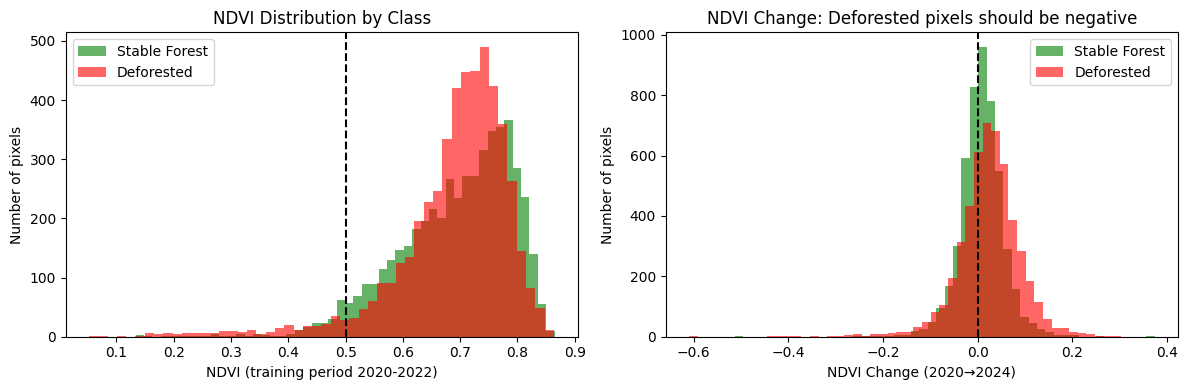

Chart saved to results/eda/data_check_ndvi.png

Mean NDVI — Deforested pixels: 0.688
Mean NDVI — Stable forest pixels: 0.693
GOOD: Stable forest has higher NDVI than deforested — labels are correct


In [6]:
if 'NDVI_train' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # NDVI distribution by class
    for label, name, color in [(0,'Stable Forest','green'),(1,'Deforested','red')]:
        subset = df[df['label']==label]['NDVI_train']
        axes[0].hist(subset, bins=50, alpha=0.6, label=name, color=color)
    axes[0].set_xlabel('NDVI (training period 2020-2022)')
    axes[0].set_ylabel('Number of pixels')
    axes[0].set_title('NDVI Distribution by Class')
    axes[0].legend()
    axes[0].axvline(x=0.5, color='black', linestyle='--', label='0.5 threshold')
    
    # NDVI change distribution
    if 'NDVI_change' in df.columns:
        for label, name, color in [(0,'Stable Forest','green'),(1,'Deforested','red')]:
            subset = df[df['label']==label]['NDVI_change']
            axes[1].hist(subset, bins=50, alpha=0.6, label=name, color=color)
        axes[1].set_xlabel('NDVI Change (2020→2024)')
        axes[1].set_ylabel('Number of pixels')
        axes[1].set_title('NDVI Change: Deforested pixels should be negative')
        axes[1].legend()
        axes[1].axvline(x=0, color='black', linestyle='--')
    
    plt.tight_layout()
    plt.savefig('results/eda/data_check_ndvi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved to results/eda/data_check_ndvi.png')
    
    # Diagnosis
    defor_ndvi_mean = df[df['label']==1]['NDVI_train'].mean()
    stable_ndvi_mean = df[df['label']==0]['NDVI_train'].mean()
    print(f'\nMean NDVI — Deforested pixels: {defor_ndvi_mean:.3f}')
    print(f'Mean NDVI — Stable forest pixels: {stable_ndvi_mean:.3f}')
    
    if stable_ndvi_mean > defor_ndvi_mean:
        print('GOOD: Stable forest has higher NDVI than deforested — labels are correct')
    else:
        print('WARNING: Something may be wrong with the labels or data')
else:
    print('NDVI_train column not found — check GEE export')

## Step 5 — Save Clean Dataset

In [ ]:
df.to_csv('data/processed/training_data_clean.csv', index=False)
print(f'Clean dataset saved: {len(df):,} pixels ready for training')


Clean dataset saved: 10,000 pixels ready for training

You are ready to run Notebook 03 — Train Model


# NATIONAL DATA (all 5 provinces)

 now on the **national** dataset since realizing dataset o fro ngyungwe can only be supported fro nyungwe parcels sincei t heavelily andmost liekly not defeorestated

In [ ]:
#  NATIONAL SECTION SETUP 
import json, os, pickle
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.cluster import DBSCAN
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

national_raw = pd.read_csv('data/raw/training_data_national.csv')
national = national_raw.drop(columns=[c for c in ['system:index','.geo','province'] if c in national_raw.columns])
print('National dataset:', national.shape[0], 'pixels across', national_raw['province'].nunique(), 'provinces')
# data engineering
# combine  columns 
def experiments_for(cols):
    A=[c for c in cols if any(x in c for x in ['NDVI','EVI','SWIR','NBR','RED','GREEN','NIR']) and 'label' not in c]
    B=A+[c for c in cols if c in ['elevation','slope','aspect']]
    C=A+[c for c in cols if any(x in c for x in ['VH','VV','ratio'])]
    D=A+[c for c in cols if any(x in c for x in ['elevation','slope','aspect','VH','VV','ratio'])]
    return {'A — Optical only':A,'B — Optical + Terrain':B,'C — Optical + Radar':C,'D — All combined':D}
# define random forest model with tuned hyperparameters
def randomforest_tuned():
    return ß(n_estimators=800, max_depth=25, min_samples_leaf=1,
        max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)

National dataset: 23319 pixels across 5 provinces


## National — Step 2: column names and label balance

In [ ]:
print('Columns:', list(national.columns))
print('\nLabel balance:', national['label'].value_counts().to_dict())
print('Province balance:', national_raw['province'].value_counts().to_dict())

Columns: ['EVI_train', 'NBR_train', 'NDVI_change', 'NDVI_test', 'NDVI_train', 'NIR_train', 'RED_train', 'SWIR_test', 'SWIR_train', 'VH_VV_ratio', 'VH_test', 'VH_train', 'VV_test', 'VV_train', 'aspect', 'elevation', 'label', 'slope']

Label balance: {1: 12003, 0: 11316}
Province balance: {'North/Amajyaruguru': 6000, 'West/Iburengerazuba': 6000, 'South/Amajyepfo': 5889, 'East/Iburasirazuba': 3167, 'Kigali City/Umujyi wa Kigali': 2263}


## National — Step 3: missing values

In [10]:
miss = nat.isna().sum()
print(miss[miss>0].to_dict() or 'No missing values')

No missing values


## National — Step 4: NDVI sanity

In [11]:
print(nat[['NDVI_train','NDVI_test','NDVI_change']].describe().round(3))

       NDVI_train  NDVI_test  NDVI_change
count   23319.000  23319.000    23319.000
mean        0.636      0.647        0.011
std         0.142      0.157        0.089
min        -0.285     -0.402       -0.734
25%         0.571      0.574       -0.025
50%         0.665      0.683        0.011
75%         0.738      0.760        0.047
max         0.874      0.889        0.675


## National — Step 5: save clean national dataset

In [12]:
nat.to_csv('data/processed/training_data_national_clean.csv', index=False)
print('Saved -> data/processed/training_data_national_clean.csv', nat.shape)

Saved -> data/processed/training_data_national_clean.csv (23319, 18)
